# Hyperparameter tuning by grid-search

In the previous notebook, we saw that hyperparameters can affect the
generalization performance of a model. In this notebook, we show how to
optimize hyperparameters using a grid-search approach.

## Our predictive model

Let us reload the dataset as we did previously:

In [1]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")

We extract the column containing the target.

In [2]:
target_name = "class"
target = adult_census[target_name]
target

0         <=50K
1         <=50K
2          >50K
3          >50K
4         <=50K
          ...  
48837     <=50K
48838      >50K
48839     <=50K
48840     <=50K
48841      >50K
Name: class, Length: 48842, dtype: str

We drop from our data the target and the `"education-num"` column which
duplicates the information from the `"education"` column.

In [3]:
data = adult_census.drop(columns=[target_name, "education-num"])
data

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,?,Some-college,Never-married,?,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


Once the dataset is loaded, we split it into a training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)

We define a pipeline as seen in the first module, to handle both numerical and
categorical features.

The first step is to select all the categorical columns.

In [5]:
from sklearn.compose import make_column_selector as selector

categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(data)

Here we use a tree-based model as a classifier (i.e.
`HistGradientBoostingClassifier`). That means:

* Numerical variables don't need scaling;
* Categorical variables can be dealt with an `OrdinalEncoder` even if the
  coding order is not meaningful;
* For tree-based models, the `OrdinalEncoder` avoids having high-dimensional
  representations.

We now build our `OrdinalEncoder` by passing it the known categories.

In [6]:
from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

We then use `make_column_transformer` to select the categorical columns and apply
the `OrdinalEncoder` to them.

In [7]:
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    remainder="passthrough",
    # Silence a deprecation warning in scikit-learn v1.6 related to how the
    # ColumnTransformer stores an attribute that we do not use in this notebook
    force_int_remainder_cols=False,
)

Finally, we use a tree-based classifier (i.e. histogram gradient-boosting) to
predict whether or not a person earns more than 50 k$ a year.

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(random_state=42, max_leaf_nodes=4),
        ),
    ]
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

## Tuning using a grid-search

In the previous exercise (M3.01) we used two nested `for` loops (one for each
hyperparameter) to test different combinations over a fixed grid of
hyperparameter values. In each iteration of the loop, we used
`cross_val_score` to compute the mean score (as averaged across
cross-validation splits), and compared those mean scores to select the best
combination. `GridSearchCV` is a scikit-learn class that implements a very
similar logic with less repetitive code. The suffix `CV` refers to the
cross-validation it runs internally (instead of the `cross_val_score` we
"hard" coded).

The `GridSearchCV` estimator takes a `param_grid` parameter which defines all
hyperparameters and their associated values. The grid-search is in charge of
creating all possible combinations and testing them.

The number of combinations is equal to the product of the number of values to
explore for each parameter. Thus, adding new parameters with their associated
values to be explored rapidly becomes computationally expensive. Because of
that, here we only explore the combination learning-rate and the maximum
number of nodes for a total of 4 x 3 = 12 combinations.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__learning_rate": (0.01, 0.1, 1, 10),  # 4 possible values
    "classifier__max_leaf_nodes": (3, 10, 30),  # 3 possible values
}  # 12 unique combinations
model_grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=2, cv=2)
model_grid_search.fit(data_train, target_train)

c:\Users\owen2\.conda\envs\data_science\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: total: 3.98 s
Wall time: 8.5 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': (0.01, ...), 'classifier__max_leaf_nodes': (3, ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

You can access the best combination of hyperparameters found by the grid
search using the `best_params_` attribute.

In [10]:
print(f"The best set of parameters is: {model_grid_search.best_params_}")

The best set of parameters is: {'classifier__learning_rate': 0.1, 'classifier__max_leaf_nodes': 30}


Once the grid-search is fitted, it can be used as any other estimator, i.e. it
has `predict` and `score` methods. Internally, it uses the model with the
best parameters found during `fit`.

Let's get the predictions for the 5 first samples using the estimator with the
best parameters:

In [11]:
model_grid_search.predict(data_test.iloc[0:5])

array([' <=50K', ' <=50K', ' >50K', ' <=50K', ' >50K'], dtype=object)

Finally, we check the accuracy of our model using the test set.

In [12]:
accuracy = model_grid_search.score(data_test, target_test)
print(
    f"The test accuracy score of the grid-search pipeline is: {accuracy:.2f}"
)

The test accuracy score of the grid-search pipeline is: 0.88


The accuracy and the best parameters of the grid-search pipeline are similar
to the ones we found in the previous exercise, where we searched the best
parameters "by hand" through a double `for` loop.

## The need for a validation set

In the previous section, the selection of the best hyperparameters was done
using the train set, coming from the initial train-test split. Then, we
evaluated the generalization performance of our tuned model on the left out
test set. This can be shown schematically as follows:

![Cross-validation tuning
diagram](../figures/cross_validation_train_test_diagram.png)

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p>This figure shows the particular case of <strong>K-fold</strong> cross-validation strategy
using <tt class="docutils literal">n_splits=5</tt> to further split the train set coming from a train-test
split. For each cross-validation split, the procedure trains a model on all
the red samples, evaluates the score of a given set of hyperparameters on the
green samples. The best combination of hyperparameters <tt class="docutils literal">best_params</tt> is selected
based on those intermediate scores.</p>
<p>Then a final model is refitted using <tt class="docutils literal">best_params</tt> on the concatenation of the
red and green samples and evaluated on the blue samples.</p>
<p class="last">The green samples are sometimes referred as the <strong>validation set</strong> to
differentiate them from the final test set in blue.</p>
</div>

In addition, we can inspect all results which are stored in the attribute
`cv_results_` of the grid-search. We filter some specific columns from these
results.

In [13]:
cv_results = pd.DataFrame(model_grid_search.cv_results_).sort_values(
    "mean_test_score", ascending=False
)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__learning_rate,param_classifier__max_leaf_nodes,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
5,0.336450,0.041611,0.069596,0.002231,0.10,30,"{'classifier__learning_rate': 0.1, 'classifier...",0.868912,0.867213,0.868063,0.000850,1
4,0.197527,0.003362,0.064559,0.001593,0.10,10,"{'classifier__learning_rate': 0.1, 'classifier...",0.866783,0.866066,0.866425,0.000359,2
7,0.104307,0.004063,0.052214,0.004548,1.00,10,"{'classifier__learning_rate': 1, 'classifier__...",0.854826,0.862899,0.858863,0.004036,3
6,0.106865,0.009750,0.054685,0.003418,1.00,3,"{'classifier__learning_rate': 1, 'classifier__...",0.853844,0.860934,0.857389,0.003545,4
3,0.138034,0.003354,0.061373,0.000944,0.10,3,"{'classifier__learning_rate': 0.1, 'classifier...",0.852752,0.853781,0.853266,0.000515,5
8,0.128626,0.002041,0.055480,0.001249,1.00,30,"{'classifier__learning_rate': 1, 'classifier__...",0.853734,0.848321,0.851028,0.002707,6
2,0.478631,0.010022,0.072185,0.002714,0.01,30,"{'classifier__learning_rate': 0.01, 'classifie...",0.840413,0.846246,0.843330,0.002917,7
1,0.226032,0.001076,0.065354,0.001793,0.01,10,"{'classifier__learning_rate': 0.01, 'classifie...",0.818956,0.816708,0.817832,0.001124,8
0,0.111420,0.002527,0.056424,0.002408,0.01,3,"{'classifier__learning_rate': 0.01, 'classifie...",0.797882,0.796451,0.797166,0.000715,9
10,0.080646,0.000714,0.051066,0.002104,10.00,10,"{'classifier__learning_rate': 10, 'classifier_...",0.742356,0.493803,0.618080,0.124277,10


Let us focus on the most interesting columns and shorten the parameter names
to remove the `"param_classifier__"` prefix for readability:

In [14]:
# get the parameter names
column_results = [f"param_{name}" for name in param_grid.keys()]
column_results += ["mean_test_score", "std_test_score", "rank_test_score"]
cv_results = cv_results[column_results]

In [15]:
def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name


cv_results = cv_results.rename(shorten_param, axis=1)
cv_results

,learning_rate,max_leaf_nodes,mean_test_score,std_test_score,rank_test_score
5,0.10,30,0.868063,0.000850,1
4,0.10,10,0.866425,0.000359,2
7,1.00,10,0.858863,0.004036,3
6,1.00,3,0.857389,0.003545,4
3,0.10,3,0.853266,0.000515,5
8,1.00,30,0.851028,0.002707,6
2,0.01,30,0.843330,0.002917,7
1,0.01,10,0.817832,0.001124,8
0,0.01,3,0.797166,0.000715,9
10,10.00,10,0.618080,0.124277,10


Given that we are tuning only 2 parameters, we can visualize the results as a
heatmap. To do so, we first need to reshape the `cv_results` into a dataframe
where:

- the rows correspond to the learning-rate values;
- the columns correspond to the maximum number of leaf;
- the content of the dataframe is the mean test scores.

In [16]:
pivoted_cv_results = cv_results.pivot_table(
    values="mean_test_score",
    index=["learning_rate"],
    columns=["max_leaf_nodes"],
)

pivoted_cv_results

max_leaf_nodes,3,10,30
learning_rate,,,
0.01,0.797166,0.817832,0.843330
0.10,0.853266,0.866425,0.868063
1.00,0.857389,0.858863,0.851028
10.00,0.283476,0.618080,0.549338


Now that we have the data in the right format, we can create the heatmap as
follows:

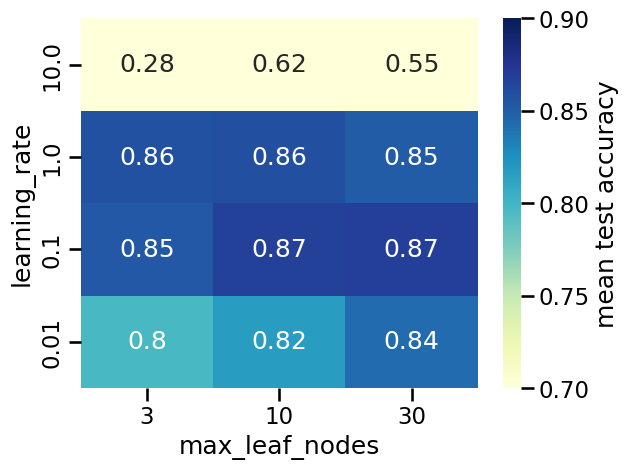

In [17]:
import seaborn as sns

ax = sns.heatmap(
    pivoted_cv_results,
    annot=True,
    cmap="YlGnBu",
    vmin=0.7,
    vmax=0.9,
    cbar_kws={"label": "mean test accuracy"},
)
ax.invert_yaxis()

The heatmap above shows the mean test accuracy (i.e., the average over
cross-validation splits) for each combination of hyperparameters, where darker
colors indicate better performance. However, notice that using colors only
allows us to visually compare the mean test score, but does not carry any
information on the standard deviation over splits, making it difficult to say
if different scores coming from different combinations lead to a significantly
better model or not.

The above tables highlights the following things:

* for too high values of `learning_rate`, the generalization performance of
  the model is degraded and adjusting the value of `max_leaf_nodes` cannot fix
  that problem;
* outside of this pathological region, we observe that the optimal choice of
  `max_leaf_nodes` depends on the value of `learning_rate`;
* in particular, we observe a "diagonal" of good models with an accuracy close
  to the maximal of 0.87: when the value of `max_leaf_nodes` is increased, one
  should decrease the value of `learning_rate` accordingly to preserve a good
  accuracy.

The precise meaning of those two parameters will be explained later.

For now we note that, in general, **there is no unique optimal parameter
setting**: 4 models out of the 12 parameter configurations reach the maximal
accuracy (up to small random fluctuations caused by the sampling of the
training set).

In this notebook we have seen:

* how to optimize the hyperparameters of a predictive model via a grid-search;
* that searching for more than two hyperparameters is too costly;
* that a grid-search does not necessarily find an optimal solution.